# Hedonic Pricing

We often try to predict the price of an asset from its observable characteristics. This is generally called **hedonic pricing**: How do the unit's characteristics determine its market price?

In the lab folder, there are three options: housing prices in pierce_county_house_sales.csv, car prices in cars_hw.csv, and airbnb rental prices in airbnb_hw.csv. If you know of another suitable dataset, please feel free to use that one.

1. Clean the data and perform some EDA and visualization to get to know the data set.
2. Transform your variables --- particularly categorical ones --- for use in your regression analysis.
3. Implement an ~80/~20 train-test split. Put the test data aside.
4. Build some simple linear models that include no transformations or interactions. Fit them, and determine their RMSE and $R^2$ on the both the training and test sets. Which of your models does the best?
5. Make partial correlation plots for each of the numeric variables in your model. Do you notice any significant non-linearities?
6. Include transformations and interactions of your variables, and build a more complex model that reflects your ideas about how the features of the asset determine its value. Determine its RMSE and $R^2$ on the training and test sets. How does the more complex model your build compare to the simpler ones?
7. Summarize your results from 1 to 6. Have you learned anything about overfitting and underfitting, or model selection?
8. If you have time, use the sklearn.linear_model.Lasso to regularize your model and select the most predictive features. Which does it select? What are the RMSE and $R^2$? We'll cover the Lasso later in detail in class.

<>:29: SyntaxWarning: invalid escape sequence '\$'
<>:29: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_6651/2878977547.py:29: SyntaxWarning: invalid escape sequence '\$'
  df['Price'] = df['Price'].replace({'\$':'', ',':''}, regex=True).astype(float)


    Host Id Host Since                                Name Neighbourhood   \
0   5162530        NaN     1 Bedroom in Prime Williamsburg       Brooklyn   
1  33134899        NaN     Sunny, Private room in Bushwick       Brooklyn   
2  39608626        NaN                Sunny Room in Harlem      Manhattan   
3       500  6/26/2008  Gorgeous 1 BR with Private Balcony      Manhattan   
4       500  6/26/2008            Trendy Times Square Loft      Manhattan   

  Property Type  Review Scores Rating (bin)        Room Type  Zipcode  Beds  \
0     Apartment                         NaN  Entire home/apt  11249.0   1.0   
1     Apartment                         NaN     Private room  11206.0   1.0   
2     Apartment                         NaN     Private room  10032.0   1.0   
3     Apartment                         NaN  Entire home/apt  10024.0   3.0   
4     Apartment                        95.0     Private room  10036.0   3.0   

   Number of Records  Number Of Reviews Price  Review Scores R

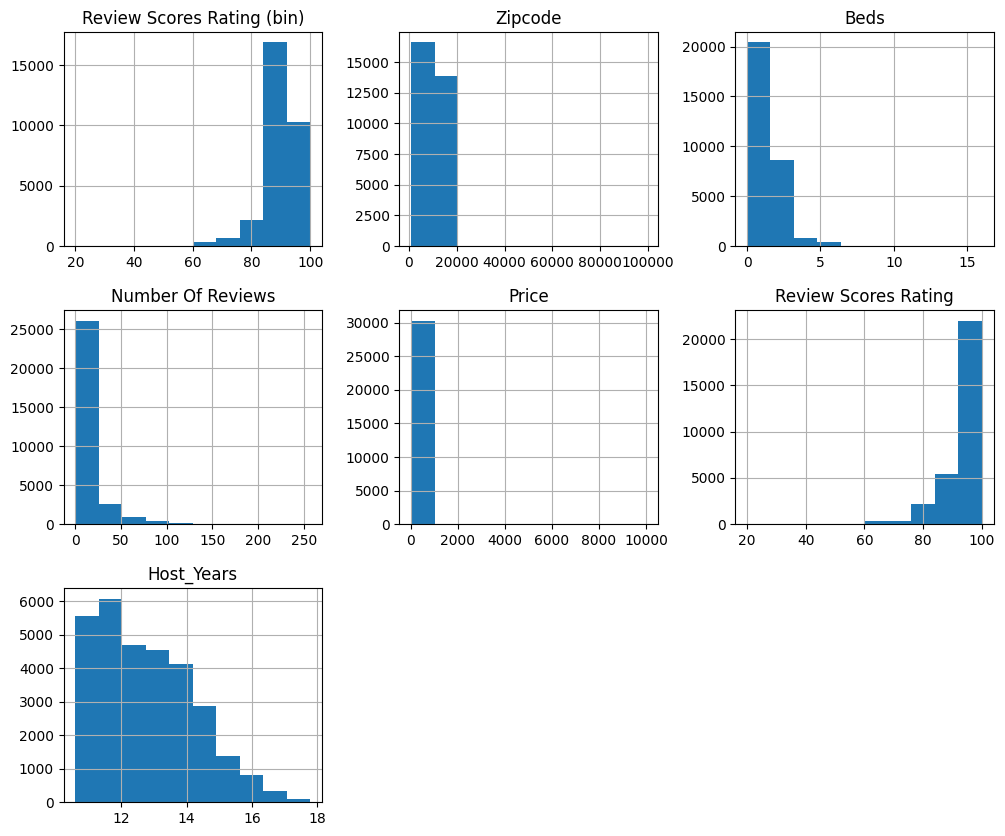

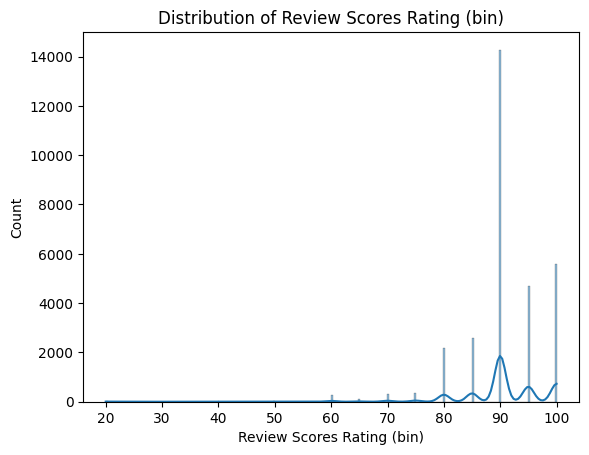

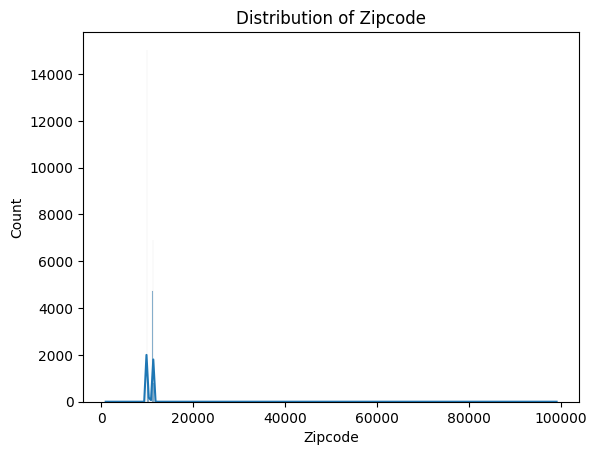

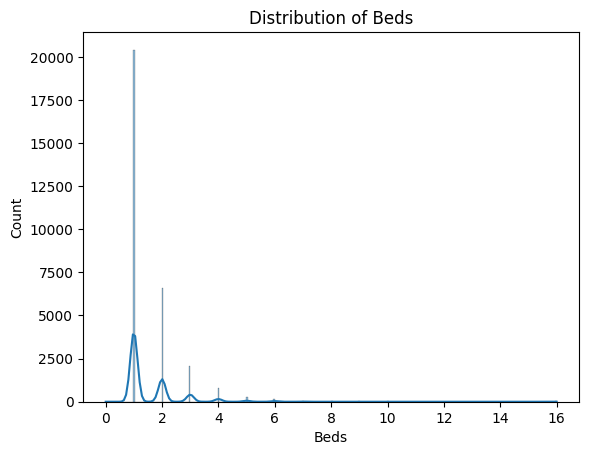

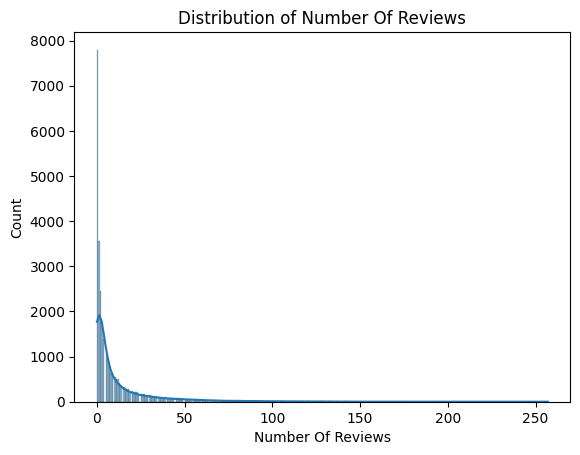

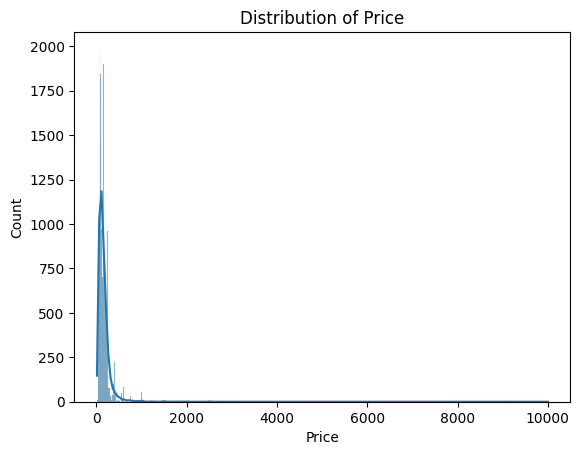

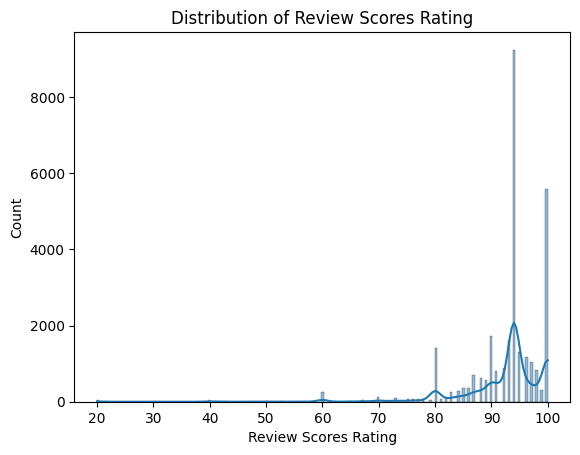

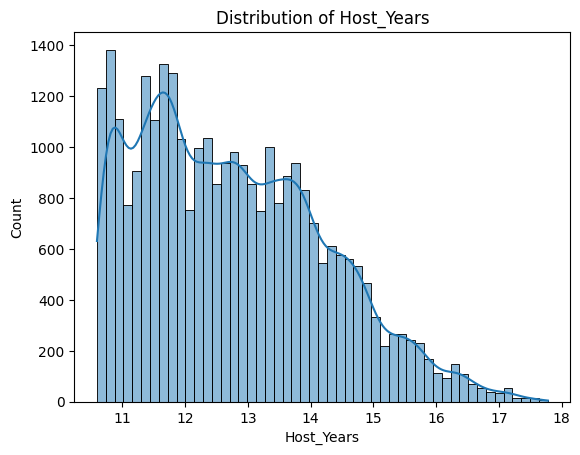

In [6]:
#1. Clean the data and perform some EDA and visualization to get to know the data set.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns

#LOAD THE DATA
df=pd.read_csv('/content/airbnb_hw.csv')
print(df.head())
print(df.info())

#CLEAN the data
df = df.drop_duplicates()
# Clean the Price column
# Drop ID and text columns that won't help
df = df.drop(columns=['Host Id', 'Name'])
# Strip whitespace from column names
df.columns = df.columns.str.strip()

# Convert Host Since to numeric because its a sentence how
df['Host_Since'] = pd.to_datetime(df['Host Since'], errors='coerce')
df['Host_Years'] = (pd.Timestamp.today() - df['Host_Since']).dt.days / 365
df = df.drop(columns=['Host Since'])

# Convert Price to numeric by remocing the dollar sign and comma
df['Price'] = df['Price'].replace({'\$':'', ',':''}, regex=True).astype(float)

# Fill missing numeric values to avoid errors in thelunear regression later
numeric_cols = ['Review Scores Rating (bin)', 'Zipcode', 'Beds', 'Review Scores Rating']
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
df = df.drop(columns=['Host_Since'])
#drop NA to avoid error
df=df.dropna()

#EDA can drscribe then maek histrograms and KDE plits
print(df.describe())
#the first time i graphed it histogram for records seemed weird and like it was a constant --> confirmed using line below that it is ALL 1 so drop column to clean data as it has no regression power
print(df['Number of Records'].value_counts())
# If it's all 1s, drop it:
df = df.drop(columns=['Number of Records'])
# Histograms
df.hist(figsize=(12,10))
plt.show()

#use seaborn to make KDEs using histplot
for col in df.select_dtypes(include=np.number).columns:
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()



These visualizations are revealing. As expected with real-world data, none of the
variables are perfectly normally distributed. Several features show significant skews driven by extreme outliers. Most notably Number of Reviews and Review Scores Rating.
The target variable, Price, is heavily right-skewed with most listings seen as clustered under 500 dollars a night but a long tail extending to $10,000+. This suggests a log transformation of Price will be necessary before regression modeling to better
satisfy linear regression's assumptions

In [7]:
#2 transform the variables
# One-hot encode categorical variables
#Create dummies for categorical columns (except Price)
categorical_cols = ['Neighbourhood', 'Property Type', 'Room Type']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)



In [12]:
# Split features and target
# When building models, use log_Price as your target to help models because price was extrememly right skewed
#if dont transform ALL models will be really bad
df['log_Price'] = np.log1p(df['Price'])

y = df['log_Price']  # NOT df['Price']
X = df.drop(columns=['Price', 'log_Price'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [15]:
#4 put test data aside and build some linear models on training set
model = LinearRegression()

#was getting weird errors were some columns were not one hot encoding and then they were objects and linear regression was failing
#used this line to double check had the correct datatypes and one hot encoding worked
print(df.dtypes)
model.fit(X_train, y_train)


# model1 : Beds + Number Of Reviews
X_train_simple1 = X_train[['Beds', 'Number Of Reviews']]
X_test_simple1  = X_test[['Beds', 'Number Of Reviews']]

# model2 Beds + Number Of Reviews + Review Scores Rating
X_train_simple2 = X_train[['Beds', 'Number Of Reviews', 'Review Scores Rating (bin)']]
X_test_simple2  = X_test[['Beds', 'Number Of Reviews', 'Review Scores Rating (bin)']]

# model3 All numeric features
X_train_simple3 = X_train.copy()
X_test_simple3  = X_test.copy()

# Put models together for iteration
models = {
    'Simple1': (X_train_simple1, X_test_simple1),
    'Simple2': (X_train_simple2, X_test_simple2),
    'Simple3': (X_train_simple3, X_test_simple3)
}

# Fit ALL models and evaluate R^2 and RMSE to assess how they performed
for name, (X_tr, X_te) in models.items():
    lr = LinearRegression()
    lr.fit(X_tr, y_train)

    train_preds = lr.predict(X_tr)
    test_preds  = lr.predict(X_te)

    print(f"\n{name}:")
    print("Train RMSE:", np.sqrt(mean_squared_error(y_train, train_preds)))
    print("Test RMSE:", np.sqrt(mean_squared_error(y_test, test_preds)))
    print("Train R2:", r2_score(y_train, train_preds))
    print("Test R2:", r2_score(y_test, test_preds))
    train_rmse_dollars = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_preds)))
    test_rmse_dollars  = np.sqrt(mean_squared_error(np.expm1(y_test),  np.expm1(test_preds)))
    print(f"Train RMSE ($): ${train_rmse_dollars:.2f} | Test RMSE ($): ${test_rmse_dollars:.2f}")

Review Scores Rating (bin)       float64
Zipcode                          float64
Beds                             float64
Number Of Reviews                  int64
Price                            float64
Review Scores Rating             float64
Host_Years                       float64
Neighbourhood_Brooklyn              bool
Neighbourhood_Manhattan             bool
Neighbourhood_Queens                bool
Neighbourhood_Staten Island         bool
Property Type_Bed & Breakfast       bool
Property Type_Boat                  bool
Property Type_Bungalow              bool
Property Type_Cabin                 bool
Property Type_Camper/RV             bool
Property Type_Castle                bool
Property Type_Chalet                bool
Property Type_Condominium           bool
Property Type_Dorm                  bool
Property Type_House                 bool
Property Type_Hut                   bool
Property Type_Lighthouse            bool
Property Type_Loft                  bool
Property Type_Ot

Simple Model 3 performed the best by far with a test R² of 0.551 and RMSE of $175.29. This makes sense
since it was fit on all available features, including the neighbourhood and property
type dummies, which clearly carry a lot of predictive power for price.

Models 1 and 2 performed poorly (R2 ~0.16 and RMSE ~$215) mostly because two features just aren't
enough to explain price variation. The small gap between Simple Model 3's train R²
(0.562) and test R² (0.551) is a good sign that it's not overfitting and generalizes
well to unseen data. That said, a 0.55 R² still leaves a lot unexplained, which
suggests there are likely some nonlinearities or interactions that cannot be properly captured through linear regression.

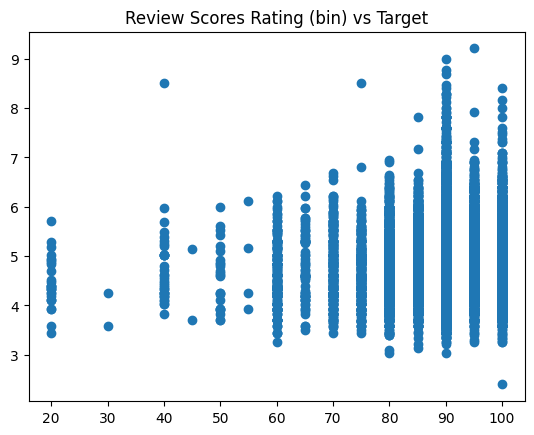

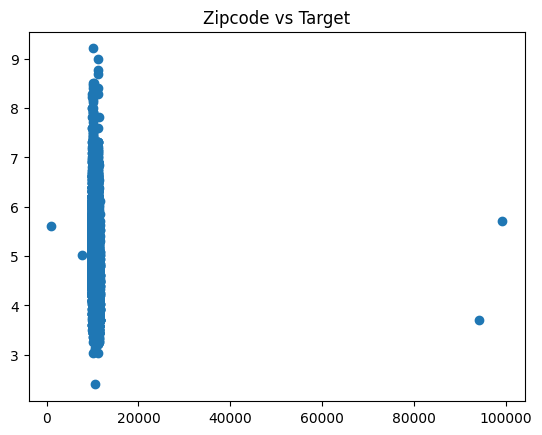

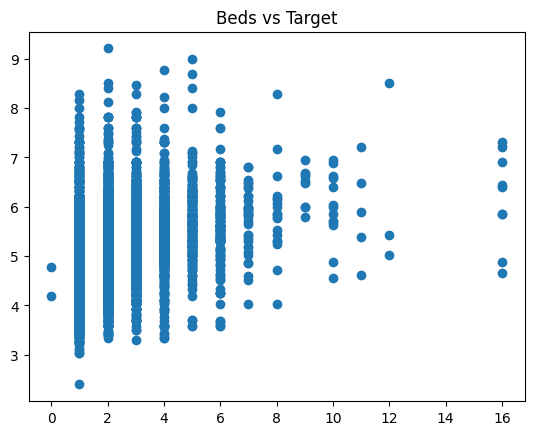

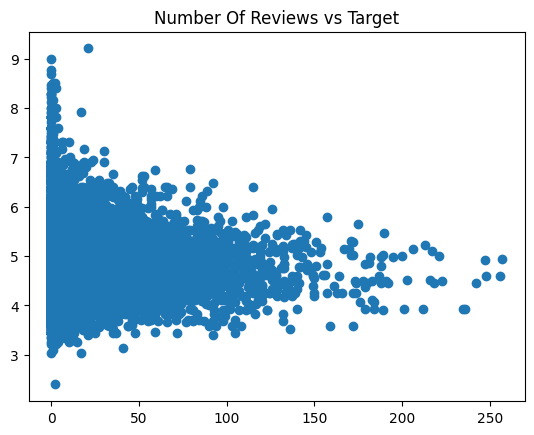

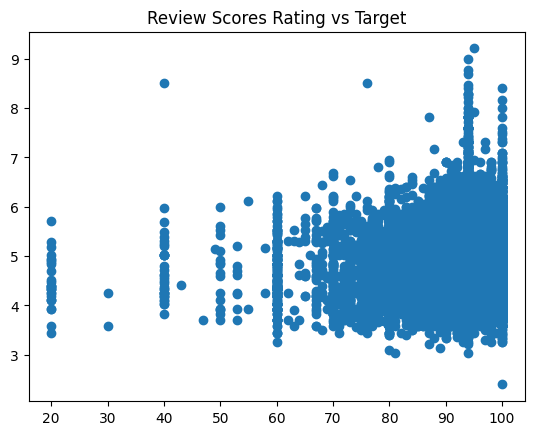

In [16]:
#Make partial correlation plots for each of the numeric variables in your model. Do you notice any significant non-linearities?
for col in X_train.columns[:5]:  # limit to first few to avoid overload
    plt.scatter(X_train[col], y_train)
    plt.title(f"{col} vs Target")
    plt.show()

These partial correlation plots reveal there are significant nonlinearities. Review Scores Rating as an example, shows a weak positive relationship with log Price but it is not linear. As review score rating increases there is a general increase in price however, at higher review score ratings there is a large variance in prices. This is showing that at higher review ratings that does not always corrleate with a higher price (which makes logical sense thinking about airbnbs; not always the most expensive ones are getting the best reviews depends a lot on quality). Similary number of reviews has a weak negative relationship, as the number of reviews increases the log price tends to be lower. However at lower amount of reviews there is extreme variation in the price again so this is nonlinear. Since beds are not a continuous variable it appears as streaks on the graph, and there doesnt appear to be a linear relationship. Zipcode is essentially useless as a numeric predictor; nearly all listings cluster in
one zip code range, forming a vertical streak with no meaningful trend. Overall, none
of these relationships look cleanly linear, which suggests that adding transformations
and interactions could improve the model significantly.

In [17]:
# Include transformations and interactions of your variables, and build a more complex model that reflects your ideas about how the features of the asset determine its value. Determine its RMSE and  𝑅2  on the training and test sets. How does the more complex model your build compare to the simpler ones?

from sklearn.preprocessing import PolynomialFeatures

X_train_trans = X_train.copy()
X_test_trans = X_test.copy()

# Only log transform numeric columns that make sense (not booleans)
skewed_cols = ['Beds', 'Number Of Reviews', 'Host_Years', 'Zipcode']
for col in skewed_cols:
    X_train_trans[col] = np.log1p(X_train_trans[col])
    X_test_trans[col] = np.log1p(X_test_trans[col])

# Add interaction term: Beds * Review Scores Rating
X_train_trans['Beds_x_Rating'] = X_train_trans['Beds'] * X_train_trans['Review Scores Rating']
X_test_trans['Beds_x_Rating']  = X_test_trans['Beds']  * X_test_trans['Review Scores Rating']

# Add polynomial term for Review Scores Rating (nonlinearity you saw in step 5)
X_train_trans['Rating_squared'] = X_train_trans['Review Scores Rating'] ** 2
X_test_trans['Rating_squared']  = X_test_trans['Review Scores Rating'] ** 2

# Refit
model2 = LinearRegression()
model2.fit(X_train_trans, y_train)

train_preds2 = model2.predict(X_train_trans)
test_preds2  = model2.predict(X_test_trans)

print("Complex Model:")
print(f"Train RMSE ($): ${np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_preds2))):.2f}")
print(f"Test RMSE ($):  ${np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(test_preds2))):.2f}")
print(f"Train R²: {r2_score(y_train, train_preds2):.4f}")
print(f"Test R²:  {r2_score(y_test, test_preds2):.4f}")

Complex Model:
Train RMSE ($): $180.01
Test RMSE ($):  $174.84
Train R²: 0.5643
Test R²:  0.5535


 Determine its RMSE and  𝑅2  on the training and test sets. How does the more complex model your build compare to the simpler ones?

 The RMSE is 174.84 on the test set, $180.01 on the training set, and train R^2 of 0.5643 and test R^2 of 0.5535.

The complex model log-transformed skewed numeric features (Beds, Number of Reviews,
Host Years, Zipcode) and added an interaction term (Beds × Review Scores Rating). The Beds × Review Scores interaction was chosen based on the intuition that a highly-rated listing with more beds likely commands a disproportionate price premium
compared to either feature alone and
a polynomial term (Rating²) to capture the nonlinearity observed in step 5. This placed more weight on things like review that I saw had some correlation with price. Despite
these additions, R² improved only marginally from 0.551 to 0.554 on the test set,
suggesting the additional complexity did not meaningfully help.